In [1]:
import os
import xml.etree.ElementTree as ET
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import seaborn as sns
from PIL import Image

IMAGES_DIR = Path("../data/images")
ANNOTATIONS_DIR = Path("../data/annotations")

CLASS_COLORS = {
    "helmet": "#2ecc71",
    "head":   "#e74c3c",
    "person": "#3498db"
}

print("Imports OK")

Imports OK


In [2]:
records = []

for xml_file in ANNOTATIONS_DIR.glob("*.xml"):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.findtext("filename")
    width = int(root.findtext("size/width"))
    height = int(root.findtext("size/height"))

    for obj in root.findall("object"):
        name = obj.findtext("name")
        xmin = int(obj.findtext("bndbox/xmin"))
        ymin = int(obj.findtext("bndbox/ymin"))
        xmax = int(obj.findtext("bndbox/xmax"))
        ymax = int(obj.findtext("bndbox/ymax"))

        bbox_w = xmax - xmin
        bbox_h = ymax - ymin

        records.append({
            "filename": filename,
            "img_width": width,
            "img_height": height,
            "class": name,
            "xmin": xmin,
            "ymin": ymin,
            "xmax": xmax,
            "ymax": ymax,
            "bbox_w": bbox_w,
            "bbox_h": bbox_h,
            "bbox_area": bbox_w * bbox_h
        })

df = pd.DataFrame(records)
print(f"Total objects: {len(df)}")
print(f"Total images:  {df['filename'].nunique()}")
print(f"\nClass distribution:")
print(df["class"].value_counts())

Total objects: 25502
Total images:  5000

Class distribution:
class
helmet    18966
head       5785
person      751
Name: count, dtype: int64


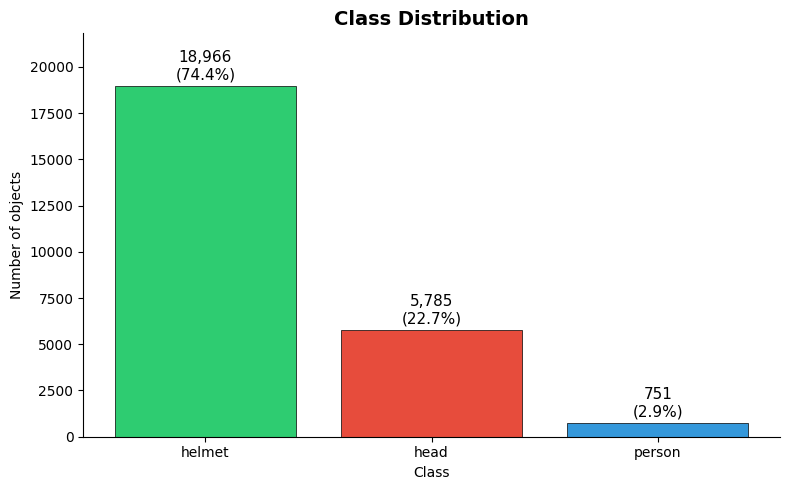

Saved to assets/


In [4]:
fig, ax = plt.subplots(figsize=(8, 5))

classes = df["class"].value_counts()
bars = ax.bar(
    classes.index,
    classes.values,
    color=[CLASS_COLORS[c] for c in classes.index],
    edgecolor="black",
    linewidth=0.5
)

for bar, val in zip(bars, classes.values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 200,
        f"{val:,}\n({val/len(df)*100:.1f}%)",
        ha="center",
        va="bottom",
        fontsize=11
    )

ax.set_title("Class Distribution", fontsize=14, fontweight="bold")
ax.set_xlabel("Class")
ax.set_ylabel("Number of objects")
ax.set_ylim(0, classes.max() * 1.15)
sns.despine()

plt.tight_layout()
plt.savefig("../assets/class_distribution.png", dpi=150)
plt.show()
print("Saved to assets/")

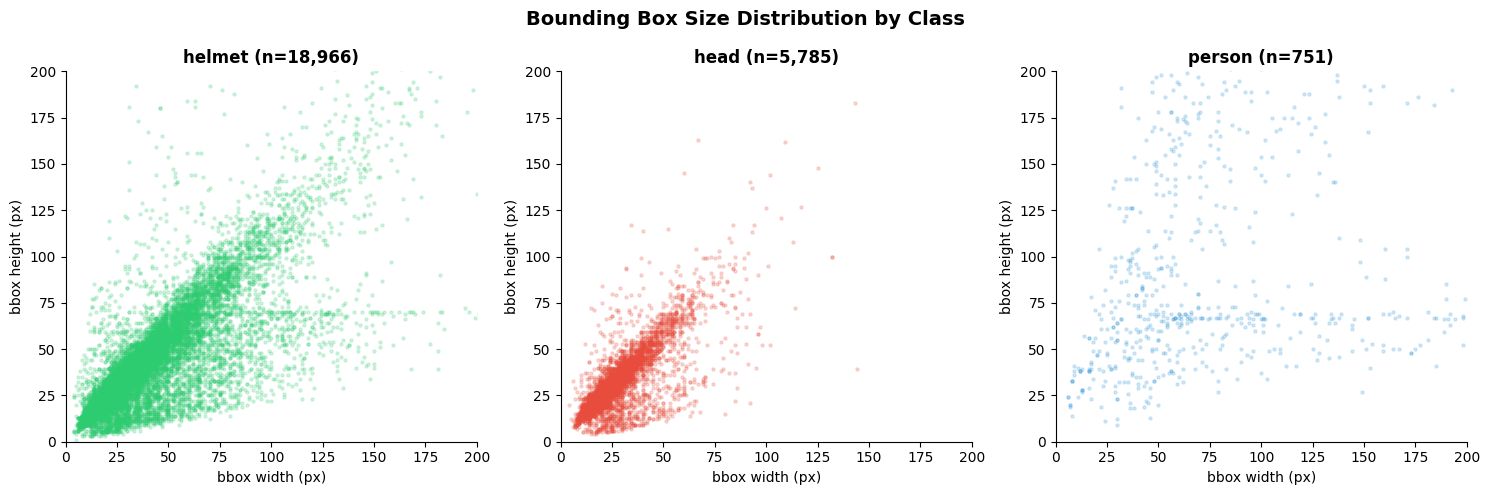

Saved to assets/


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, cls in zip(axes, ["helmet", "head", "person"]):
    subset = df[df["class"] == cls]
    
    ax.scatter(
        subset["bbox_w"],
        subset["bbox_h"],
        alpha=0.2,
        s=5,
        color=CLASS_COLORS[cls]
    )
    
    ax.set_title(f"{cls} (n={len(subset):,})", fontsize=12, fontweight="bold")
    ax.set_xlabel("bbox width (px)")
    ax.set_ylabel("bbox height (px)")
    ax.set_xlim(0, 200)
    ax.set_ylim(0, 200)
    sns.despine()

fig.suptitle("Bounding Box Size Distribution by Class", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/bbox_distribution.png", dpi=150)
plt.show()
print("Saved to assets/")

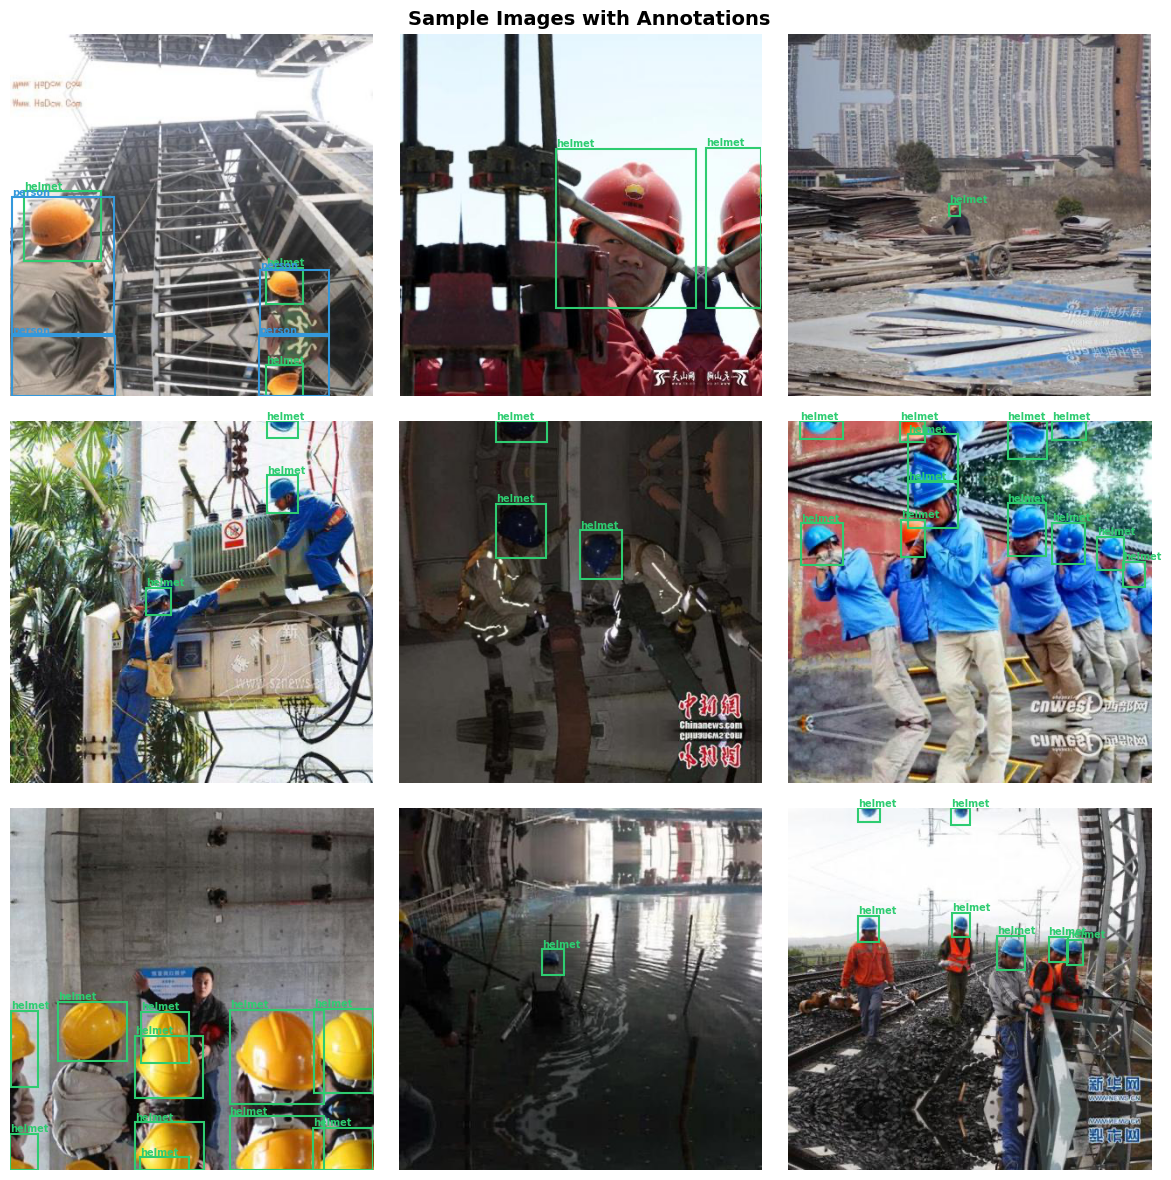

Saved to assets/


In [6]:
import random

sample_files = random.sample(list(ANNOTATIONS_DIR.glob("*.xml")), 9)

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for ax, xml_file in zip(axes.flatten(), sample_files):
    tree = ET.parse(xml_file)
    root = tree.getroot()

    filename = root.findtext("filename")
    img = Image.open(IMAGES_DIR / filename)
    ax.imshow(img)

    for obj in root.findall("object"):
        name = obj.findtext("name")
        xmin = int(obj.findtext("bndbox/xmin"))
        ymin = int(obj.findtext("bndbox/ymin"))
        xmax = int(obj.findtext("bndbox/xmax"))
        ymax = int(obj.findtext("bndbox/ymax"))

        rect = patches.Rectangle(
            (xmin, ymin),
            xmax - xmin,
            ymax - ymin,
            linewidth=1.5,
            edgecolor=CLASS_COLORS[name],
            facecolor="none"
        )
        ax.add_patch(rect)
        ax.text(
            xmin, ymin - 3,
            name,
            color=CLASS_COLORS[name],
            fontsize=7,
            fontweight="bold"
        )

    ax.axis("off")

fig.suptitle("Sample Images with Annotations", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig("../assets/sample_annotations.png", dpi=150)
plt.show()
print("Saved to assets/")

In [7]:
print("Bounding box statistics by class:\n")
stats = df.groupby("class")[["bbox_w", "bbox_h", "bbox_area"]].describe().round(1)
print(stats)

Bounding box statistics by class:

         bbox_w                                              bbox_h         \
          count  mean   std  min   25%   50%    75%    max    count   mean   
class                                                                        
head     5785.0  28.1  14.7  4.0  18.0  24.0   34.0  144.0   5785.0   31.9   
helmet  18966.0  38.9  27.6  4.0  20.0  30.0   49.0  282.0  18966.0   40.6   
person    751.0  90.1  65.1  6.0  45.0  68.0  125.0  404.0    751.0  115.7   

        ...               bbox_area                                           \
        ...    75%    max     count     mean      std    min     25%     50%   
class   ...                                                                    
head    ...   39.0  206.0    5785.0   1083.4   1328.1   48.0   378.0   675.0   
helmet  ...   51.0  333.0   18966.0   2199.8   3671.9    5.0   440.0   980.0   
person  ...  175.0  412.0     751.0  12175.1  14905.5  112.0  3137.0  6916.0   

               